In [1]:
import pandas as pd

In [8]:
df_bookings = pd.read_csv('datasets/fact_bookings_clean.csv')
df_date = pd.read_csv('datasets/dim_date_clean.csv')
df_hotels = pd.read_csv('datasets/dim_hotels.csv')
df_rooms = pd.read_csv('datasets/dim_rooms.csv')
df_aggr_bookings = pd.read_csv('datasets/fact_aggregated_bookings_clean.csv')

1. What is an average occupancy rate in each of the room category?

In [9]:
df_aggr_bookings

,Unnamed: 0,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy_percentage %
0,0,16559,1-May-22,RT1,25,30.0,83.33
1,1,19562,1-May-22,RT1,28,30.0,93.33
2,2,19563,1-May-22,RT1,23,30.0,76.67
3,3,17558,1-May-22,RT1,30,19.0,157.89
4,4,16558,1-May-22,RT1,18,19.0,94.74
...,...,...,...,...,...,...,...
9195,9195,16563,31-Jul-22,RT4,13,18.0,72.22
9196,9196,16559,31-Jul-22,RT4,13,18.0,72.22
9197,9197,17558,31-Jul-22,RT4,3,6.0,50.00
9198,9198,19563,31-Jul-22,RT4,3,6.0,50.00


In [11]:
df_aggr_bookings.groupby('room_category')['occupancy_percentage %'].mean().round(2)

room_category
RT1    58.22
RT2    58.04
RT3    58.03
RT4    59.30
Name: occupancy_percentage %, dtype: float64

In [12]:
df_rooms

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


In [ ]:
df_merged = pd.merge(df_aggr_bookings, df_rooms, left_on='room_category', right_on='room_id')
df_merged

,Unnamed: 0,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy_percentage %,room_id,room_class
0,0,16559,1-May-22,RT1,25,30.0,83.33,RT1,Standard
1,1,19562,1-May-22,RT1,28,30.0,93.33,RT1,Standard
2,2,19563,1-May-22,RT1,23,30.0,76.67,RT1,Standard
3,3,17558,1-May-22,RT1,30,19.0,157.89,RT1,Standard
4,4,16558,1-May-22,RT1,18,19.0,94.74,RT1,Standard
...,...,...,...,...,...,...,...,...,...
9195,9195,16563,31-Jul-22,RT4,13,18.0,72.22,RT4,Presidential
9196,9196,16559,31-Jul-22,RT4,13,18.0,72.22,RT4,Presidential
9197,9197,17558,31-Jul-22,RT4,3,6.0,50.00,RT4,Presidential
9198,9198,19563,31-Jul-22,RT4,3,6.0,50.00,RT4,Presidential


In [15]:
df_merged.drop("Unnamed: 0", axis=1)

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy_percentage %,room_id,room_class
0,16559,1-May-22,RT1,25,30.0,83.33,RT1,Standard
1,19562,1-May-22,RT1,28,30.0,93.33,RT1,Standard
2,19563,1-May-22,RT1,23,30.0,76.67,RT1,Standard
3,17558,1-May-22,RT1,30,19.0,157.89,RT1,Standard
4,16558,1-May-22,RT1,18,19.0,94.74,RT1,Standard
...,...,...,...,...,...,...,...,...
9195,16563,31-Jul-22,RT4,13,18.0,72.22,RT4,Presidential
9196,16559,31-Jul-22,RT4,13,18.0,72.22,RT4,Presidential
9197,17558,31-Jul-22,RT4,3,6.0,50.00,RT4,Presidential
9198,19563,31-Jul-22,RT4,3,6.0,50.00,RT4,Presidential


In [16]:
df_merged.groupby('room_class')['occupancy_percentage %'].mean()

room_class
Elite           58.040278
Premium         58.028213
Presidential    59.300461
Standard        58.224247
Name: occupancy_percentage %, dtype: float64

In [19]:
df_merged = df_merged.drop(['room_category','Unnamed: 0'], axis=1)

In [20]:
df_merged

,property_id,check_in_date,successful_bookings,capacity,occupancy_percentage %,room_id,room_class
0,16559,1-May-22,25,30.0,83.33,RT1,Standard
1,19562,1-May-22,28,30.0,93.33,RT1,Standard
2,19563,1-May-22,23,30.0,76.67,RT1,Standard
3,17558,1-May-22,30,19.0,157.89,RT1,Standard
4,16558,1-May-22,18,19.0,94.74,RT1,Standard
...,...,...,...,...,...,...,...
9195,16563,31-Jul-22,13,18.0,72.22,RT4,Presidential
9196,16559,31-Jul-22,13,18.0,72.22,RT4,Presidential
9197,17558,31-Jul-22,3,6.0,50.00,RT4,Presidential
9198,19563,31-Jul-22,3,6.0,50.00,RT4,Presidential


2. Print average occupancy rate per city

In [31]:
df_merged = pd.merge(df_hotels, df_merged, on='property_id')
df_merged

,property_id,property_name,category,city,check_in_date,successful_bookings,capacity,occupancy_percentage %,room_id,room_class
0,16558,Atliq Grands,Luxury,Delhi,1-May-22,18,19.0,94.74,RT1,Standard
1,16558,Atliq Grands,Luxury,Delhi,1-May-22,21,22.0,95.45,RT2,Elite
2,16558,Atliq Grands,Luxury,Delhi,1-May-22,8,8.0,100.00,RT3,Premium
3,16558,Atliq Grands,Luxury,Delhi,1-May-22,3,3.0,100.00,RT4,Presidential
4,16558,Atliq Grands,Luxury,Delhi,2-May-22,12,19.0,63.16,RT1,Standard
...,...,...,...,...,...,...,...,...,...,...
9195,17564,Atliq Seasons,Business,Mumbai,30-Jul-22,8,17.0,47.06,RT4,Presidential
9196,17564,Atliq Seasons,Business,Mumbai,31-Jul-22,8,16.0,50.00,RT1,Standard
9197,17564,Atliq Seasons,Business,Mumbai,31-Jul-22,19,40.0,47.50,RT2,Elite
9198,17564,Atliq Seasons,Business,Mumbai,31-Jul-22,11,24.0,45.83,RT3,Premium


In [32]:
a = df_merged.groupby('city')['occupancy_percentage %'].mean().round(2)
for city, m in a.items():
    print(f"For {city} average occupancy rate is : {m}")

For Bangalore average occupancy rate is : 56.59
For Delhi average occupancy rate is : 61.61
For Hyderabad average occupancy rate is : 58.14
For Mumbai average occupancy rate is : 57.94


<Axes: xlabel='city'>

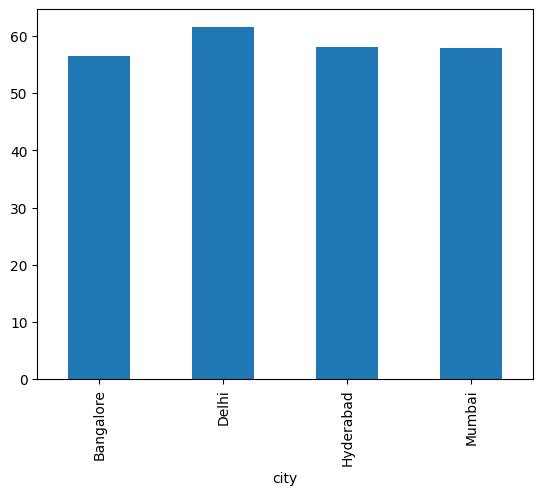

In [33]:
df_merged.groupby('city')['occupancy_percentage %'].mean().round(2).plot(kind='bar')

3. When was the occupancy better? weekdays or weekends

In [34]:
df_merged.head()

,property_id,property_name,category,city,check_in_date,successful_bookings,capacity,occupancy_percentage %,room_id,room_class
0,16558,Atliq Grands,Luxury,Delhi,1-May-22,18,19.0,94.74,RT1,Standard
1,16558,Atliq Grands,Luxury,Delhi,1-May-22,21,22.0,95.45,RT2,Elite
2,16558,Atliq Grands,Luxury,Delhi,1-May-22,8,8.0,100.00,RT3,Premium
3,16558,Atliq Grands,Luxury,Delhi,1-May-22,3,3.0,100.00,RT4,Presidential
4,16558,Atliq Grands,Luxury,Delhi,2-May-22,12,19.0,63.16,RT1,Standard


In [37]:
df_date = df_date.drop('Unnamed: 0',axis=1)

In [38]:
df_date

,date,week no,day_type,month,year,week_no
0,2022-05-01,W 19,weekend,May,2022,W 17
1,2022-05-02,W 19,weekday,May,2022,W 18
2,2022-05-03,W 19,weekday,May,2022,W 18
3,2022-05-04,W 19,weekday,May,2022,W 18
4,2022-05-05,W 19,weekday,May,2022,W 18
...,...,...,...,...,...,...
87,2022-07-27,W 31,weekday,Jul,2022,W 30
88,2022-07-28,W 31,weekday,Jul,2022,W 30
89,2022-07-29,W 31,weekday,Jul,2022,W 30
90,2022-07-30,W 31,weekend,Jul,2022,W 30


In [40]:
df_merged['check_in_date'] = pd.to_datetime(df_merged['check_in_date'])
df_merged

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_19900\403375673.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_merged['check_in_date'] = pd.to_datetime(df_merged['check_in_date'])


,property_id,property_name,category,city,check_in_date,successful_bookings,capacity,occupancy_percentage %,room_id,room_class
0,16558,Atliq Grands,Luxury,Delhi,2022-05-01,18,19.0,94.74,RT1,Standard
1,16558,Atliq Grands,Luxury,Delhi,2022-05-01,21,22.0,95.45,RT2,Elite
2,16558,Atliq Grands,Luxury,Delhi,2022-05-01,8,8.0,100.00,RT3,Premium
3,16558,Atliq Grands,Luxury,Delhi,2022-05-01,3,3.0,100.00,RT4,Presidential
4,16558,Atliq Grands,Luxury,Delhi,2022-05-02,12,19.0,63.16,RT1,Standard
...,...,...,...,...,...,...,...,...,...,...
9195,17564,Atliq Seasons,Business,Mumbai,2022-07-30,8,17.0,47.06,RT4,Presidential
9196,17564,Atliq Seasons,Business,Mumbai,2022-07-31,8,16.0,50.00,RT1,Standard
9197,17564,Atliq Seasons,Business,Mumbai,2022-07-31,19,40.0,47.50,RT2,Elite
9198,17564,Atliq Seasons,Business,Mumbai,2022-07-31,11,24.0,45.83,RT3,Premium


In [47]:
df_date['date'] = pd.to_datetime(df_date['date'])
df_date.dtypes

date        datetime64[us]
week no                str
day_type               str
month                  str
year                 int64
week_no                str
dtype: object

In [48]:
df_merged = pd.merge(df_merged, df_date, left_on='check_in_date', right_on='date')
df_merged

,property_id,property_name,category,city,check_in_date,successful_bookings,capacity,occupancy_percentage %,room_id,room_class,date,week no,day_type,month,year,week_no
0,16558,Atliq Grands,Luxury,Delhi,2022-05-01,18,19.0,94.74,RT1,Standard,2022-05-01,W 19,weekend,May,2022,W 17
1,16558,Atliq Grands,Luxury,Delhi,2022-05-01,21,22.0,95.45,RT2,Elite,2022-05-01,W 19,weekend,May,2022,W 17
2,16558,Atliq Grands,Luxury,Delhi,2022-05-01,8,8.0,100.00,RT3,Premium,2022-05-01,W 19,weekend,May,2022,W 17
3,16558,Atliq Grands,Luxury,Delhi,2022-05-01,3,3.0,100.00,RT4,Presidential,2022-05-01,W 19,weekend,May,2022,W 17
4,16558,Atliq Grands,Luxury,Delhi,2022-05-02,12,19.0,63.16,RT1,Standard,2022-05-02,W 19,weekday,May,2022,W 18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9195,17564,Atliq Seasons,Business,Mumbai,2022-07-30,8,17.0,47.06,RT4,Presidential,2022-07-30,W 31,weekend,Jul,2022,W 30
9196,17564,Atliq Seasons,Business,Mumbai,2022-07-31,8,16.0,50.00,RT1,Standard,2022-07-31,W 32,weekend,Jul,2022,W 30
9197,17564,Atliq Seasons,Business,Mumbai,2022-07-31,19,40.0,47.50,RT2,Elite,2022-07-31,W 32,weekend,Jul,2022,W 30
9198,17564,Atliq Seasons,Business,Mumbai,2022-07-31,11,24.0,45.83,RT3,Premium,2022-07-31,W 32,weekend,Jul,2022,W 30


In [52]:
a = df_merged.groupby('day_type')['occupancy_percentage %'].mean().round(2)
for type, m in a.items():
    print(f"Occupancy rate on {type} is : {m}")

if a['weekend'] > a['weekday']:
    print("Occupancy rate is greater on weekends than weekdays")
else:
    print("Occupancy rate is greater on weekdays than weekends")

Occupancy rate on weekday is : 51.82
Occupancy rate on weekend is : 74.24
Occupancy rate is greater on weekends than weekdays


<Axes: xlabel='day_type'>

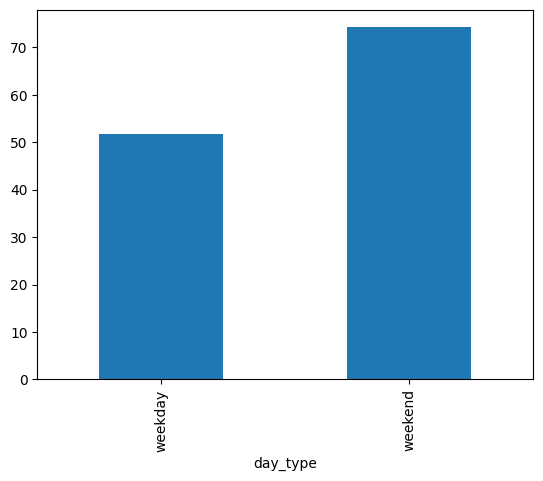

In [55]:
df_merged.groupby('day_type')['occupancy_percentage %'].mean().round(2).plot(kind='bar')

**Exercise-1. Print revenue realized per hotel type**

In [ ]:
df_bookings

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
1,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
2,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
3,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100
...,...,...,...,...,...,...,...,...,...,...,...,...
134568,Jul312217564RT45,17564,30-07-22,31-07-22,1/8/2022,2.0,RT4,others,2.0,Checked Out,32300,32300
134569,Jul312217564RT46,17564,29-07-22,31-07-22,3/8/2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300
134570,Jul312217564RT48,17564,30-07-22,31-07-22,2/8/2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920
134571,Jul312217564RT49,17564,29-07-22,31-07-22,1/8/2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300


In [63]:
df_merged = pd.merge(df_bookings, df_hotels, on="property_id")

In [64]:
df_merged

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi
1,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Atliq Grands,Luxury,Delhi
2,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,Atliq Grands,Luxury,Delhi
3,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi
4,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100,Atliq Grands,Luxury,Delhi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134568,Jul312217564RT45,17564,30-07-22,31-07-22,1/8/2022,2.0,RT4,others,2.0,Checked Out,32300,32300,Atliq Seasons,Business,Mumbai
134569,Jul312217564RT46,17564,29-07-22,31-07-22,3/8/2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300,Atliq Seasons,Business,Mumbai
134570,Jul312217564RT48,17564,30-07-22,31-07-22,2/8/2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920,Atliq Seasons,Business,Mumbai
134571,Jul312217564RT49,17564,29-07-22,31-07-22,1/8/2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300,Atliq Seasons,Business,Mumbai


In [67]:
df_merged.groupby(['property_name','category'])['revenue_realized'].mean()

property_name  category
Atliq Bay      Luxury      12158.479143
Atliq Blu      Luxury      11968.978710
Atliq City     Business    12254.456693
Atliq Exotica  Luxury      13664.074921
Atliq Grands   Luxury      12417.765811
Atliq Palace   Business    12871.189968
Atliq Seasons  Business    16600.536297
Name: revenue_realized, dtype: float64

**Exercise-2 Print average rating per city**

In [68]:
df_merged.groupby('city')['ratings_given'].mean()

city
Bangalore    3.407681
Delhi        3.779298
Hyderabad    3.661041
Mumbai       3.650545
Name: ratings_given, dtype: float64

**Exercise-3 Print a pie chart of revenue realized per booking platform**

<Axes: >

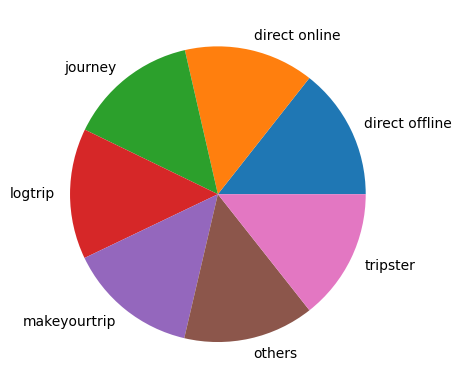

In [70]:
df_merged.groupby('booking_platform')['revenue_realized'].mean().plot(kind='pie')

In [73]:
import matplotlib.pyplot as plt

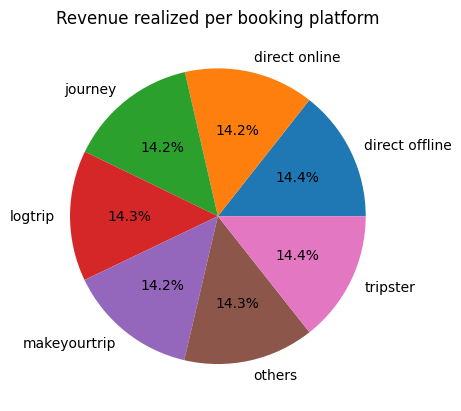

In [79]:
a = df_merged.groupby('booking_platform')['revenue_realized'].mean()
plt.title('Revenue realized per booking platform')
plt.pie(
    a,
    labels = a.index,
    autopct='%1.1f%%'
)
plt.show()